# Inspect the generated Liu2024 graph dataset

`readmoabbliu.ipynb` inspects the **local raw source recordings**. This notebook inspects the
**opposite end of the pipeline**: the saved feature dataset that `generate_dataset.py` produced from
those recordings at `data/moabb/Graph-Liu2024-VersionOne/`, following the two-node/six-edge-variant
layout in [DATASET_PLAN.md](DATASET_PLAN.md).

It loads the saved arrays through the same `saved_dataset.load_dataset()` API that experiment code
uses, re-runs the checks from `validation.py` against them, and plots node features, edge/connectivity
matrices, and one assembled graph so the generated dataset can be inspected visually — not just
programmatically. It does not recompute anything from the source EDF files; everything here reads only
the already-saved `.npy`/`.json`/`.tsv` files.

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data/moabb/Graph-Liu2024-VersionOne").is_dir():
            return candidate
    raise FileNotFoundError(
        "Generated dataset not found under data/moabb/Graph-Liu2024-VersionOne. "
        "Run generate_dataset.py first; this notebook does not generate data itself."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
DATASET_ROOT = REPO_ROOT / "data/moabb/Graph-Liu2024-VersionOne"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")

Repo root: /workspaces/EEG
Dataset root: /workspaces/EEG/data/moabb/Graph-Liu2024-VersionOne


In [2]:
import json

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

from src.datautils.graphdataversionone.saved_dataset import load_dataset
from src.datautils.graphdataversionone.validation import validate_saved_dataset

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"NetworkX version: {nx.__version__}")

NumPy version: 2.4.6
pandas version: 3.0.5
NetworkX version: 3.6.1


## Load the saved dataset

`load_dataset()` memory-maps every array read-only and checks the metadata/array schema (shapes,
dtypes, band order) before returning — this alone already exercises part of the same schema checking
`validation.py` does.

In [3]:
dataset = load_dataset(DATASET_ROOT)

print(f"Trials saved: {len(dataset)}")
print(f"Node variants: {list(dataset.nodes)}")
print(f"Edge variants: {list(dataset.edges)}")
print(f"edge_index shape: {dataset.edge_index.shape}")
print(f"Node array dtype: {dataset.nodes['without_csd'].dtype}, writeable: {dataset.nodes['without_csd'].flags.writeable}")

Trials saved: 2000
Node variants: ['without_csd', 'csd']
Edge variants: ['wpli_without_csd', 'wpli_csd', 'plv_without_csd', 'plv_csd', 'icoh_abs_without_csd', 'icoh_abs_csd']
edge_index shape: (2, 812)
Node array dtype: float32, writeable: False


## Metadata and calculation settings

Everything needed to reproduce or interpret the saved features — channel/band/feature order, dB
references, connectivity settings, and software versions — is recorded once in `metadata.json`, per
the plan's "Save the calculation configuration and software versions with the dataset."

In [4]:
metadata = dataset.metadata

overview = pd.Series({
    "dataset": metadata["dataset"],
    "schema_version": metadata["schema_version"],
    "status": metadata["status"],
    "n_samples": metadata["n_samples"],
    "n_subjects": len(metadata["subjects"]),
    "expected_trials_per_subject": metadata["expected_trials_per_subject"],
    "class_mapping": metadata["class_mapping"],
    "connectivity_backend": metadata["connectivity_backend"],
    "pilot": metadata["pilot"],
})
display(overview)

print("Node feature names:", metadata["node_feature_names"])
print("Band names:", metadata["band_names"])
print("Edge variants:", list(metadata["edge_variants"]))
print()
print("Welch settings:", metadata["generation_settings"]["welch"])
print("CSD settings:", metadata["generation_settings"]["csd"])
print()
print("Software versions:")
display(pd.Series(metadata["software_versions"]))

dataset                                                  Liu2024
schema_version                                                 1
status                                                  complete
n_samples                                                   2000
n_subjects                                                    50
expected_trials_per_subject                                   40
class_mapping                  {'left_hand': 0, 'right_hand': 1}
connectivity_backend                                         mne
pilot                                                      False
dtype: object

Node feature names: ['delta_power_db', 'theta_power_db', 'alpha_power_db', 'beta_power_db', 'gamma_power_db', 'spectral_entropy']
Band names: ['delta', 'theta', 'alpha', 'beta', 'gamma']
Edge variants: ['wpli_without_csd', 'plv_without_csd', 'icoh_abs_without_csd', 'wpli_csd', 'plv_csd', 'icoh_abs_csd']

Welch settings: {'window': 'hann', 'segment_seconds': 2.0, 'overlap_fraction': 0.5, 'detrend': 'constant', 'scaling': 'density', 'average': 'mean', 'integration': 'scipy.integrate.simpson', 'power_floor_in_reference_units': 1e-12}
CSD settings: {'montage': 'standard_1020', 'sphere': 'auto-fit recorded per subject', 'lambda2': 1e-05, 'stiffness': 4, 'n_legendre_terms': 50}

Software versions:


numpy                2.4.6
scipy               1.17.1
pandas               3.0.5
mne                 1.12.1
mne-connectivity     0.9.0
dtype: str

## Re-run the saved-file validation

`validate_saved_dataset()` reloads every array and checks shapes/dtypes, finite values, entropy and
connectivity ranges, complete/symmetric edge ordering, and label/subject/trial alignment — this call
re-runs exactly that, live, against the files on disk right now.

This dataset was generated with `connectivity_backend: "mne"` (confirmed in the metadata above) —
purely through the CPU MNE reference implementation, with no CUDA reimplementation in the loop. An
earlier version of this dataset was generated with an optional CUDA backend and its
`validation_report.json` additionally recorded a CPU-vs-CUDA cross-check; that backend has since been
removed (see `DATASET_PLAN.md`), and the comparison below confirms the current, leaner report format
this dataset actually ships with.

In [5]:
live_report = validate_saved_dataset(DATASET_ROOT)
print("Freshly recomputed (validation.py, as it exists now):")
display(pd.Series({k: v for k, v in live_report.items() if k not in ("subject_counts", "subject_class_counts")}))

on_disk_report = json.loads((DATASET_ROOT / "validation_report.json").read_text())
extra_keys = [key for key in on_disk_report if key not in live_report]
print("\nKeys in the archived validation_report.json beyond what validate_saved_dataset() returns:", extra_keys)
display(pd.Series({key: on_disk_report[key] for key in extra_keys}))

assert live_report["n_samples"] == on_disk_report["n_samples"] == metadata["n_samples"]
assert live_report["class_counts"] == on_disk_report["class_counts"]
print("\nCounts that both reports compute agree.")

Freshly recomputed (validation.py, as it exists now):


n_samples                                          2000
n_subjects                                           50
class_counts    {'left_hand': 1000, 'right_hand': 1000}
dtype: object


Keys in the archived validation_report.json beyond what validate_saved_dataset() returns: ['elapsed_seconds']


elapsed_seconds    4154.761113
dtype: float64


Counts that both reports compute agree.


## Subject and class balance

The plan requires 40 trials per subject (20 left-hand, 20 right-hand) for the completed dataset.

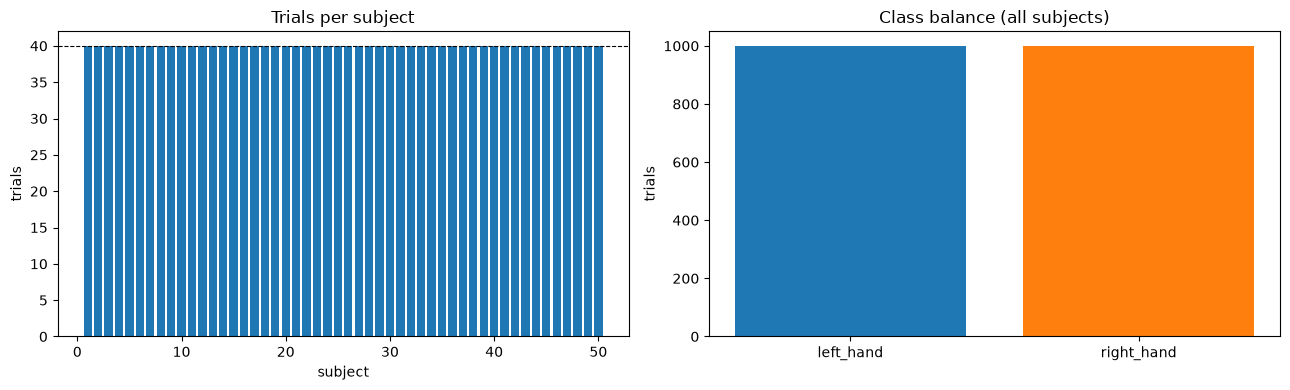

40 trials/subject and a 1000/1000 class split, both confirmed directly from samples.tsv.


In [6]:
samples = pd.DataFrame(dataset.samples)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
trials_per_subject = samples.groupby("subject").size()
axes[0].bar(trials_per_subject.index, trials_per_subject.values, color="tab:blue")
axes[0].axhline(40, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Trials per subject")
axes[0].set_xlabel("subject")
axes[0].set_ylabel("trials")

class_counts = samples["target"].value_counts()
axes[1].bar(class_counts.index, class_counts.values, color=["tab:blue", "tab:orange"])
axes[1].set_title("Class balance (all subjects)")
axes[1].set_ylabel("trials")
fig.tight_layout()
plt.show()

assert (trials_per_subject == 40).all()
assert class_counts.to_dict() == {"left_hand": 1000, "right_hand": 1000}
print("40 trials/subject and a 1000/1000 class split, both confirmed directly from samples.tsv.")

## Trial window lengths

Source marker boundaries are preserved rather than cropped to a fixed length, so saved windows are
2,000–2,002 samples (4.000–4.004 s at 500 Hz); node/edge features still come out at a fixed shape
because the feature functions handle the small jitter internally.

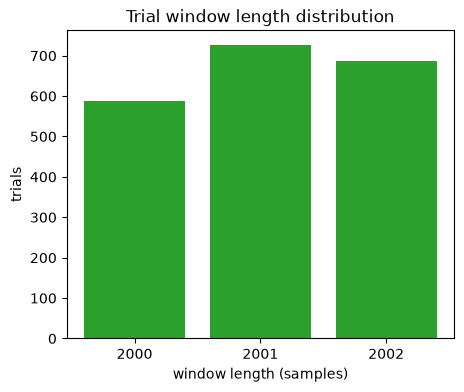

{2000: np.int64(587), 2001: np.int64(726), 2002: np.int64(687)}


In [7]:
window_lengths = (samples["stop_sample"] - samples["start_sample"]).value_counts().sort_index()

fig, axis = plt.subplots(figsize=(5, 4))
axis.bar(window_lengths.index.astype(str), window_lengths.values, color="tab:green")
axis.set_xlabel("window length (samples)")
axis.set_ylabel("trials")
axis.set_title("Trial window length distribution")
plt.show()

print(dict(window_lengths))
assert set(window_lengths.index) <= {2000, 2001, 2002}

## Pick one example trial

Subject 1, trial 0 — the same trial `test_source.py` and the CPU-reference spot checks used.

In [8]:
example = samples[(samples["subject"] == 1) & (samples["trial_index"] == 0)]
index = int(example.index[0])
display(example.T.rename(columns={index: "value"}))

print(f"Array row index: {index}")
print(f"Label: {int(dataset.labels[index])} ({example['target'].iloc[0]})")

,value
subject,1
trial_index,0
target,left_hand
label,0
start_sample,1003
stop_sample,3005
sampling_frequency_hz,500.0
source_file,/workspaces/EEG/data/moabb/MNE-liu2024-data/fi...
trial_type,1
source_event_row,1


Array row index: 0
Label: 0 (left_hand)


## Node features: without CSD vs CSD

Both variants keep the same six features (`node_feature_names` above) in the same channel order;
only the input signal differs. Because CSD power is in dB relative to a different physical reference
(1 (µV/m²)² instead of 1 µV²), the two variants are plotted side by side rather than overlaid, so the
different absolute scale isn't mistaken for a like-for-like power comparison.

In [9]:
channels = metadata["channel_names"]
node_feature_names = metadata["node_feature_names"]

without_csd = pd.DataFrame(dataset.nodes["without_csd"][index], index=channels, columns=node_feature_names)
csd = pd.DataFrame(dataset.nodes["csd"][index], index=channels, columns=node_feature_names)

print("without_csd (first 5 channels):")
display(without_csd.head().round(3))
print("csd (first 5 channels):")
display(csd.head().round(3))

without_csd (first 5 channels):


,delta_power_db,theta_power_db,alpha_power_db,beta_power_db,gamma_power_db,spectral_entropy
FP1,24.389999,16.618,8.979,10.055,9.265,0.580
FP2,26.250000,18.514,10.489,6.721,3.934,0.535
Fz,17.458000,10.926,6.220,4.957,1.916,0.575
F3,18.856001,11.933,7.962,11.832,11.407,0.747
F4,14.055000,9.185,4.478,7.978,6.761,0.777


csd (first 5 channels):


,delta_power_db,theta_power_db,alpha_power_db,beta_power_db,gamma_power_db,spectral_entropy
FP1,79.190002,70.514999,63.876999,69.348999,68.541000,0.487
FP2,81.190002,72.837997,65.352997,66.570999,67.667999,0.566
Fz,76.237999,68.459999,63.076000,62.959000,61.173000,0.554
F3,73.024002,69.947998,65.735001,72.148003,71.363998,0.865
F4,73.357002,63.393002,60.787998,66.635002,65.292000,0.675


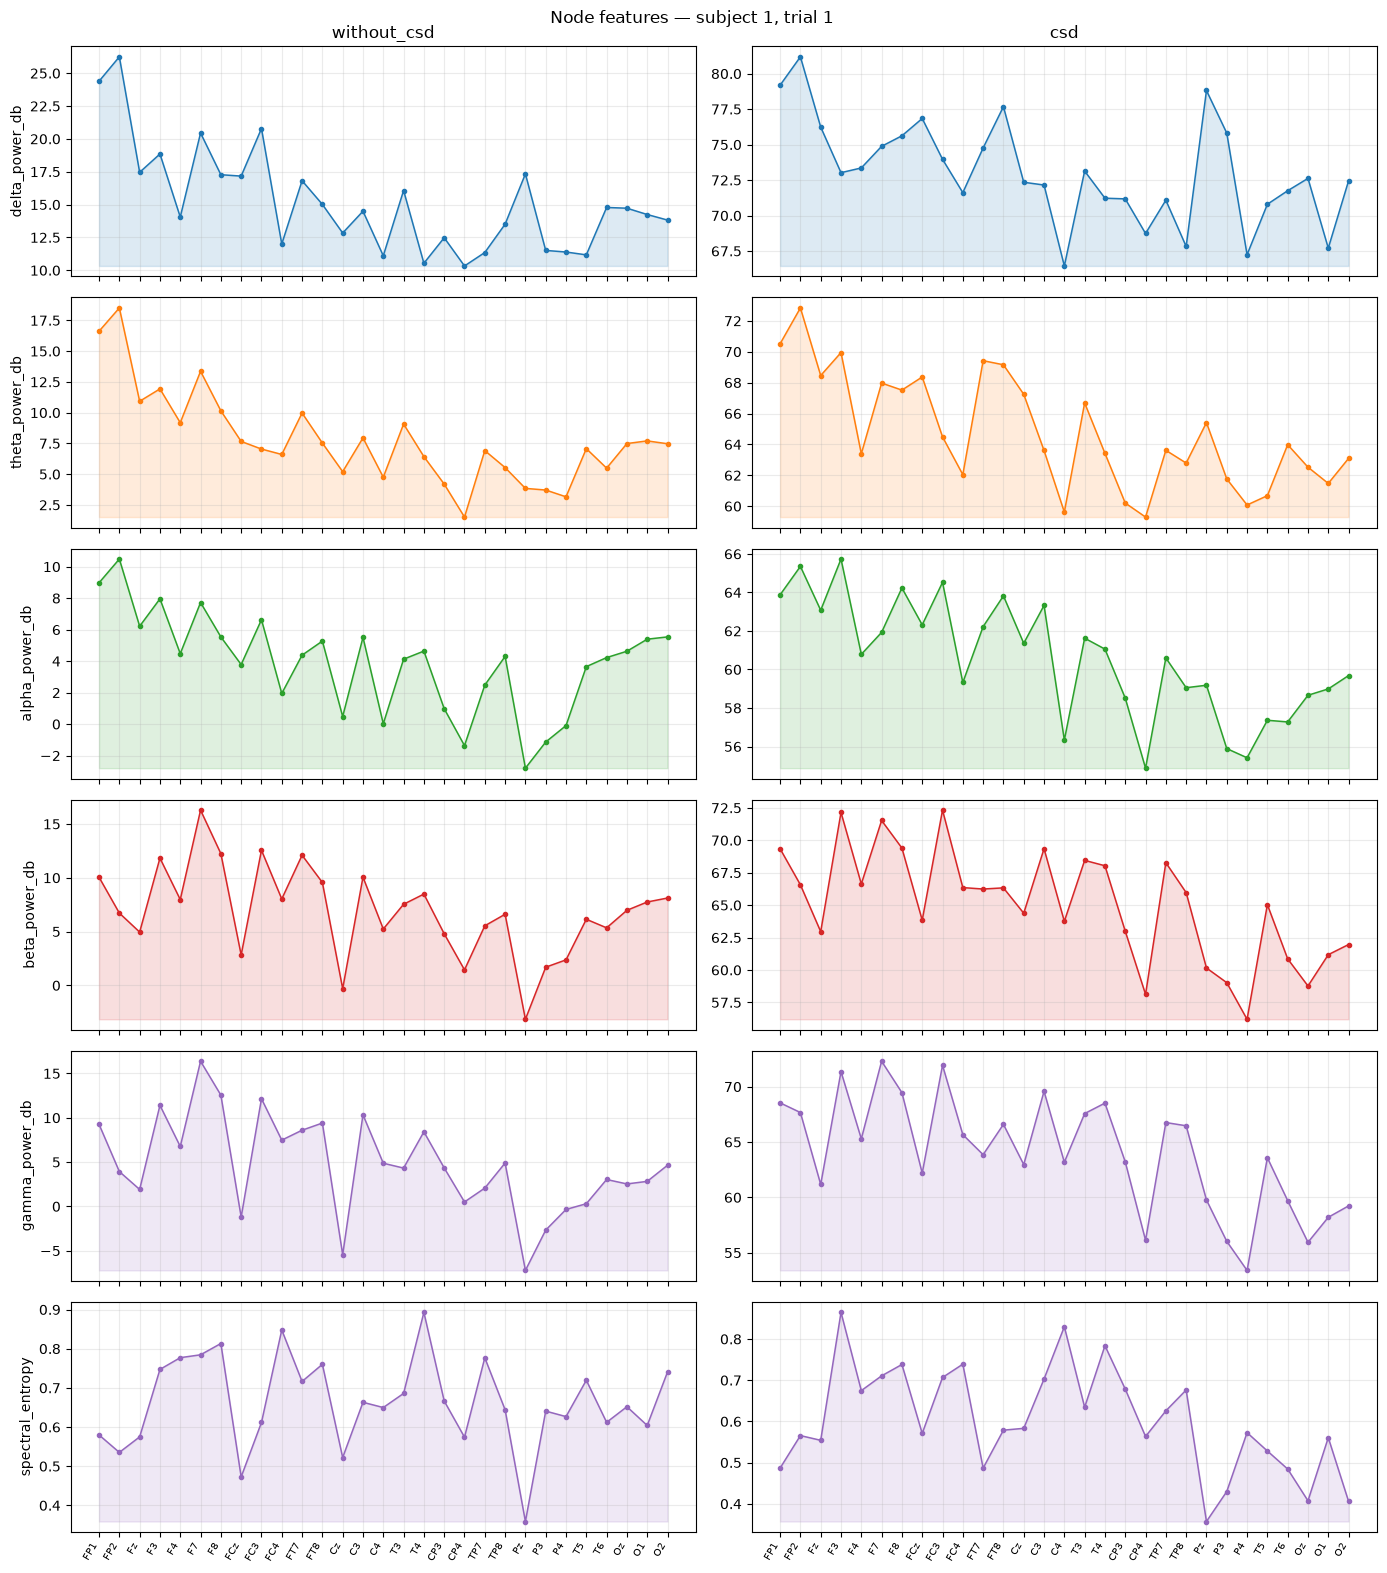

In [10]:
positions_x = np.arange(len(channels))
fig, axes = plt.subplots(6, 2, figsize=(14, 16), sharex=True)
for row, feature in enumerate(node_feature_names):
    for col, (variant_name, table) in enumerate((("without_csd", without_csd), ("csd", csd))):
        axis = axes[row, col]
        values = table[feature].to_numpy()
        color = "tab:purple" if feature == "spectral_entropy" else f"C{row}"
        axis.plot(positions_x, values, marker="o", markersize=3, linewidth=1.1, color=color)
        axis.fill_between(positions_x, values, values.min(), alpha=0.15, color=color)
        axis.grid(alpha=0.25)
        if col == 0:
            axis.set_ylabel(feature)
        if row == 0:
            axis.set_title(variant_name)
for axis in axes[-1]:
    axis.set_xticks(positions_x)
    axis.set_xticklabels(channels, rotation=60, ha="right", fontsize=7)
fig.suptitle(f"Node features — subject {example['subject'].iloc[0]}, trial {example['trial_index'].iloc[0] + 1}")
fig.tight_layout()
plt.show()

## Reconstruct edge adjacency matrices from the saved `edge_index` + `edge_attr`

`edge_index` stores each of the 406 unordered pairs in both directions (812 rows total); scattering
`edge_attr` back onto those indices reproduces the dense, symmetric, zero-diagonal adjacency matrix
per band — the same structure `readmoabbliu.ipynb` builds when it first derives these features.

In [11]:
edge_index = dataset.edge_index
n_channels = len(channels)
band_names = metadata["band_names"]


def adjacency_from_edges(edge_values):
    """Scatter (n_edges, n_bands) edge_attr back onto an (n_bands, n_channels, n_channels) adjacency."""
    adjacency = np.zeros((edge_values.shape[1], n_channels, n_channels), dtype=edge_values.dtype)
    adjacency[:, edge_index[0], edge_index[1]] = edge_values.T
    return adjacency


wpli_without_csd = adjacency_from_edges(dataset.edges["wpli_without_csd"][index])

assert wpli_without_csd.shape == (5, 29, 29)
assert np.allclose(wpli_without_csd, wpli_without_csd.transpose(0, 2, 1))
assert np.allclose(np.diagonal(wpli_without_csd, axis1=1, axis2=2), 0.0)
assert wpli_without_csd.min() >= 0.0 and wpli_without_csd.max() <= 1.0

print(f"wPLI (without CSD) adjacency shape: {wpli_without_csd.shape}")
print(f"Range: [{wpli_without_csd.min():.4f}, {wpli_without_csd.max():.4f}]")
print("Symmetric with a zero diagonal in every band, as required by the plan.")

wPLI (without CSD) adjacency shape: (5, 29, 29)
Range: [0.0000, 0.9939]
Symmetric with a zero diagonal in every band, as required by the plan.


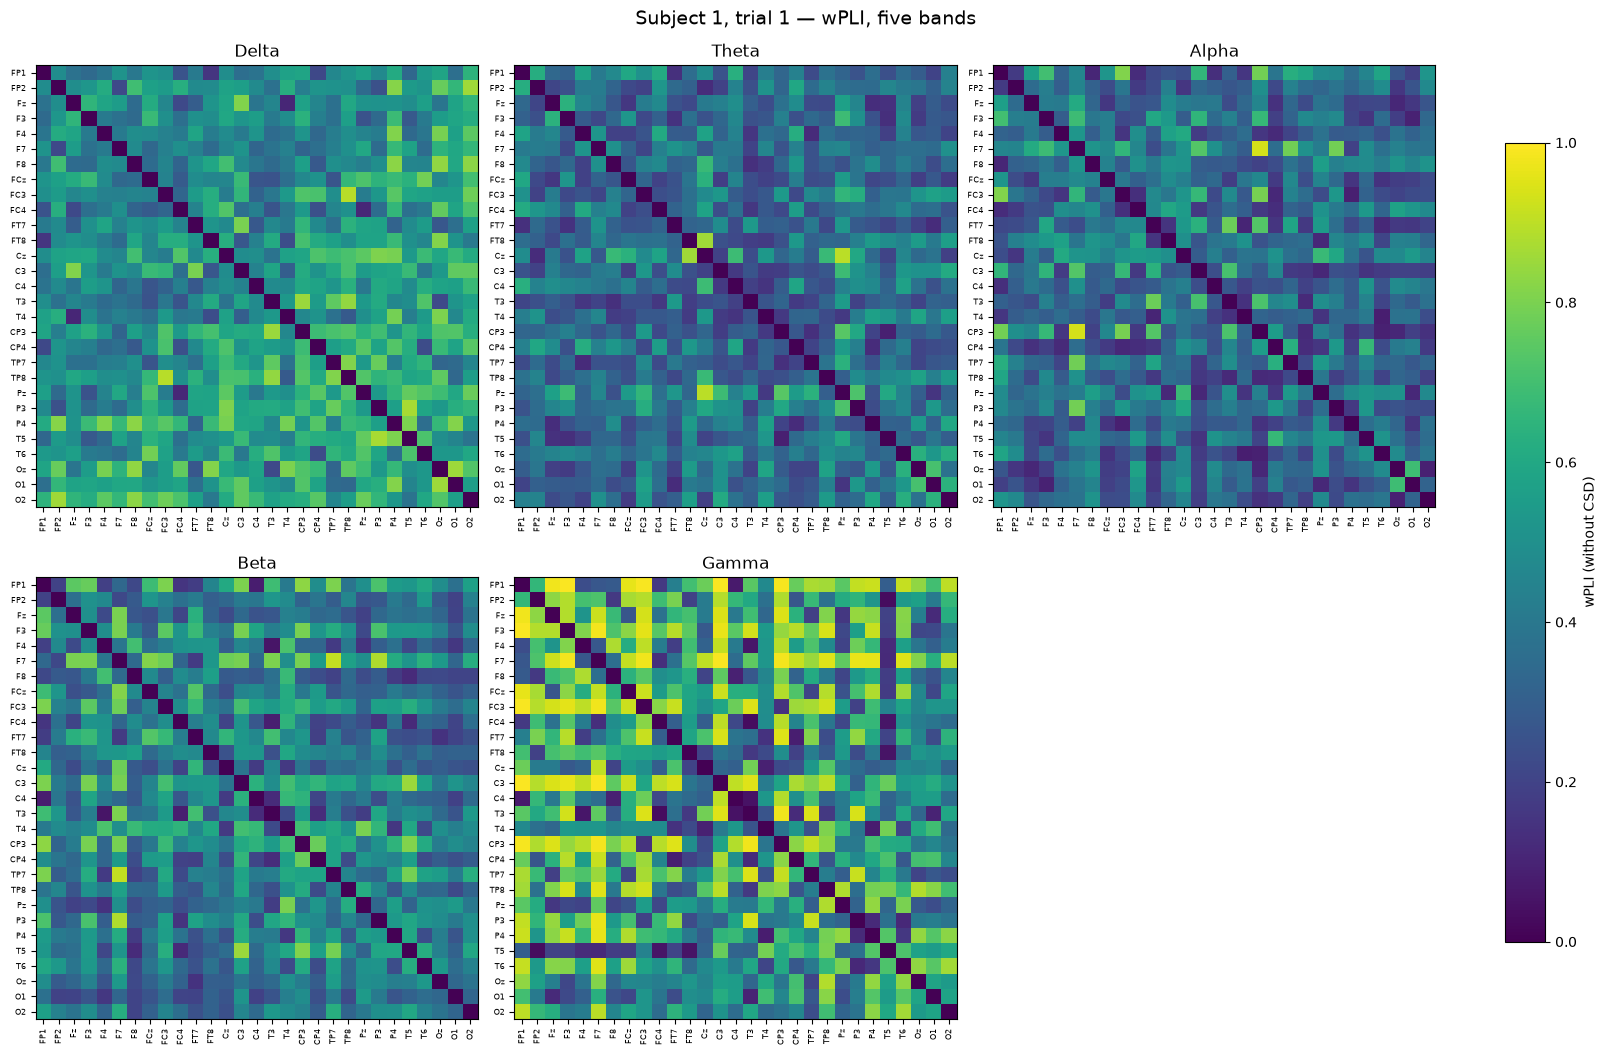

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10.5), constrained_layout=True)
axes = axes.ravel()
for band_idx, (axis, band) in enumerate(zip(axes, band_names)):
    image = axis.imshow(wpli_without_csd[band_idx], vmin=0, vmax=1, cmap="viridis")
    axis.set_title(band.title())
    axis.set_xticks(np.arange(n_channels))
    axis.set_yticks(np.arange(n_channels))
    axis.set_xticklabels(channels, rotation=90, fontsize=6)
    axis.set_yticklabels(channels, fontsize=6)
axes[-1].axis("off")
fig.colorbar(image, ax=axes.tolist(), shrink=0.8, label="wPLI (without CSD)")
fig.suptitle(f"Subject {example['subject'].iloc[0]}, trial {example['trial_index'].iloc[0] + 1} — wPLI, five bands", fontsize=14)
plt.show()

## Compare the three connectivity methods (alpha band, without CSD)

wPLI and iCoh discount zero-lag (volume-conducted) coupling, so both read visibly lower and sparser
than PLV here — the qualitative pattern the plan's connectivity methods are chosen to separate.

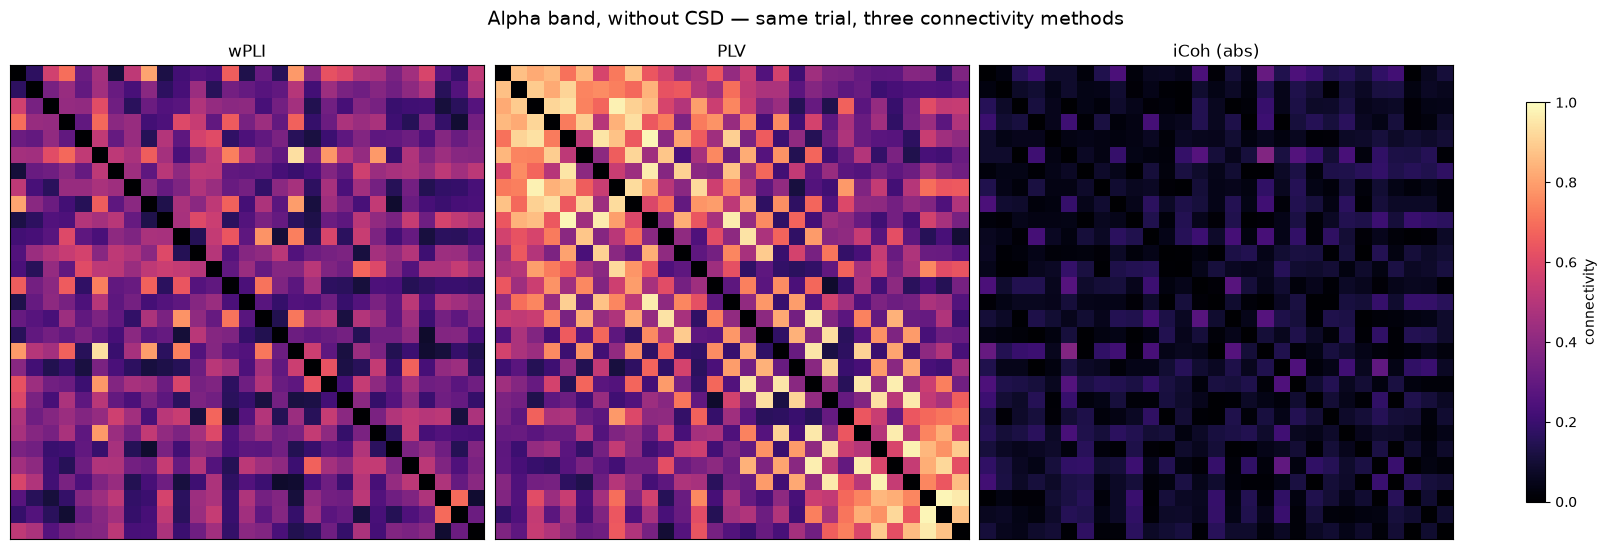

In [13]:
alpha_index = band_names.index("alpha")
plv_without_csd = adjacency_from_edges(dataset.edges["plv_without_csd"][index])
icoh_without_csd = adjacency_from_edges(dataset.edges["icoh_abs_without_csd"][index])

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)
for axis, (name, adjacency) in zip(
    axes, (("wPLI", wpli_without_csd), ("PLV", plv_without_csd), ("iCoh (abs)", icoh_without_csd))
):
    image = axis.imshow(adjacency[alpha_index], vmin=0, vmax=1, cmap="magma")
    axis.set_title(name)
    axis.set_xticks([])
    axis.set_yticks([])
fig.colorbar(image, ax=axes.tolist(), shrink=0.8, label="connectivity")
fig.suptitle("Alpha band, without CSD — same trial, three connectivity methods", fontsize=14)
plt.show()

## CSD vs. without-CSD (wPLI, alpha band)

CSD is a spatial (surface-Laplacian) filter applied before connectivity, so it sharpens the spatial
pattern by suppressing volume-conducted spread between nearby electrodes.

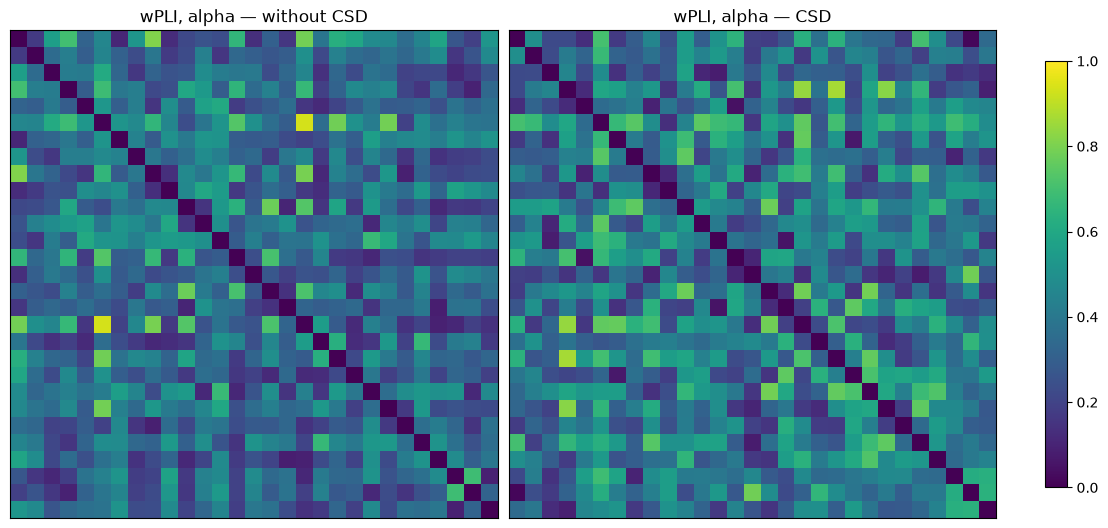

In [14]:
wpli_csd = adjacency_from_edges(dataset.edges["wpli_csd"][index])

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), constrained_layout=True)
for axis, (name, adjacency) in zip(axes, (("without CSD", wpli_without_csd), ("CSD", wpli_csd))):
    image = axis.imshow(adjacency[alpha_index], vmin=0, vmax=1, cmap="viridis")
    axis.set_title(f"wPLI, alpha — {name}")
    axis.set_xticks([])
    axis.set_yticks([])
fig.colorbar(image, ax=axes.tolist(), shrink=0.8)
plt.show()

## The graph object a model would consume: `get_graph()`

This is the actual public API (`saved_dataset.get_graph` / `SavedDataset.get_graph`) that combines an
independently chosen node variant with one or more edge variants into a single graph sample —
returned as plain NumPy (shown here), or as a `torch_geometric.data.Data` with `as_pyg=True`.

In [15]:
graph = dataset.get_graph(index, node_variant="csd", edge_variants=("wpli_without_csd", "plv_csd"))

print("x:", graph["x"].shape)
print("edge_index:", graph["edge_index"].shape)
print("edge_attr:", graph["edge_attr"].shape)
print("y:", graph["y"], f"({example['target'].iloc[0]})")
print("node_feature_names:", graph["node_feature_names"])
print("edge_feature_names:", graph["edge_feature_names"])

# get_graph() must hand back copies, never the dataset's own memory-mapped arrays.
graph["x"][0, 0] = 0.0
assert dataset.nodes["csd"][index, 0, 0] != 0.0
print("\nConfirmed: mutating the returned graph does not touch the underlying memory-mapped dataset.")

x: (29, 6)
edge_index: (2, 812)
edge_attr: (812, 10)
y: 0 (left_hand)
node_feature_names: ['delta_power_db', 'theta_power_db', 'alpha_power_db', 'beta_power_db', 'gamma_power_db', 'spectral_entropy']
edge_feature_names: ['wpli_without_csd:delta', 'wpli_without_csd:theta', 'wpli_without_csd:alpha', 'wpli_without_csd:beta', 'wpli_without_csd:gamma', 'plv_csd:delta', 'plv_csd:theta', 'plv_csd:alpha', 'plv_csd:beta', 'plv_csd:gamma']

Confirmed: mutating the returned graph does not touch the underlying memory-mapped dataset.


## Draw the graph: nodes = CSD alpha power, edges = strongest wPLI alpha connections

Electrodes are laid out at their real analysis-montage head-frame positions (`x` = right, `y` =
anterior, from `metadata["montage"]["analysis_montage"]`), viewed from above with the nose up — the
same positions `preprocessing.attach_analysis_montage()` attaches before CSD. The saved dataset itself
stores **all 406 undirected pairs with no threshold** (per the plan); the top decile of alpha-band
wPLI is kept here **only so the drawing stays legible**.

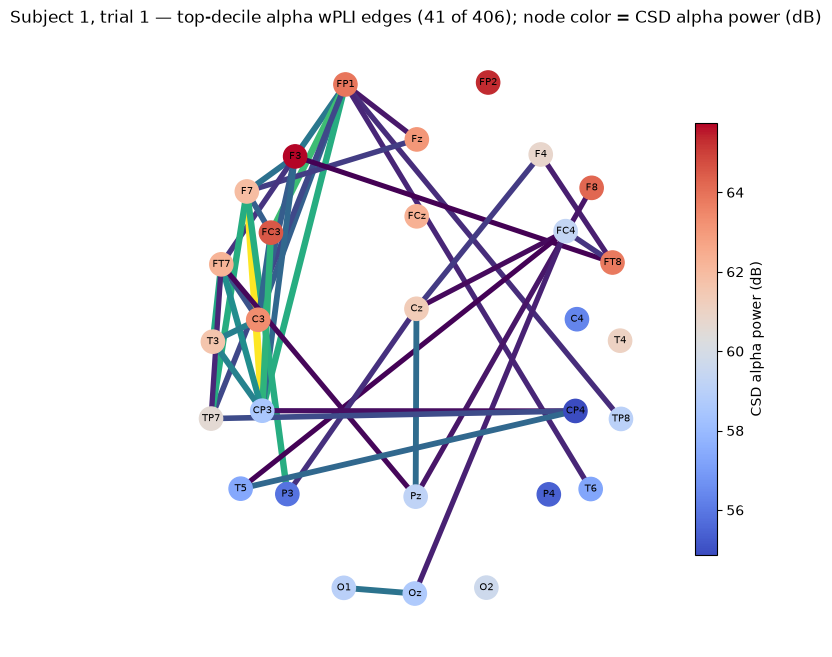

In [16]:
analysis_positions = metadata["montage"]["analysis_montage"]["channel_positions"]
layout = {channel: (analysis_positions[channel][0], analysis_positions[channel][1]) for channel in channels}

graph_nx = nx.Graph()
graph_nx.add_nodes_from(channels)
undirected = wpli_without_csd[alpha_index][edge_index[0], edge_index[1]]
threshold = np.quantile(undirected, 0.9)
for k in range(edge_index.shape[1]):
    i, j = int(edge_index[0, k]), int(edge_index[1, k])
    weight = float(wpli_without_csd[alpha_index, i, j])
    if i < j and weight >= threshold:
        graph_nx.add_edge(channels[i], channels[j], weight=weight)

node_color = csd["alpha_power_db"].to_numpy()
edges_drawn = list(graph_nx.edges(data="weight"))

fig, axis = plt.subplots(figsize=(8, 8))
node_artist = nx.draw_networkx_nodes(graph_nx, layout, node_color=node_color, cmap="coolwarm", node_size=280, ax=axis)
nx.draw_networkx_edges(
    graph_nx, layout,
    edgelist=[(u, v) for u, v, w in edges_drawn],
    width=[1.5 + 4 * w for u, v, w in edges_drawn],
    edge_color=[w for u, v, w in edges_drawn], edge_cmap=plt.cm.viridis, ax=axis,
)
nx.draw_networkx_labels(graph_nx, layout, font_size=7, ax=axis)
axis.set_title(
    f"Subject {example['subject'].iloc[0]}, trial {example['trial_index'].iloc[0] + 1} — "
    f"top-decile alpha wPLI edges ({graph_nx.number_of_edges()} of {edge_index.shape[1] // 2}); "
    "node color = CSD alpha power (dB)"
)
axis.axis("off")
fig.colorbar(node_artist, ax=axis, shrink=0.7, label="CSD alpha power (dB)")
plt.show()

## Dataset-wide checks (the same invariants `validation.py` checks, run here directly)

Everything above looked at one trial. These assertions load every saved array in full and check the
whole dataset at once, mirroring `readmoabbliu.ipynb`'s own inline-`assert` style.

In [17]:
for variant_name, array in dataset.nodes.items():
    values = np.asarray(array)
    assert values.shape == (len(dataset), 29, 6)
    assert np.isfinite(values).all()
    entropy_column = values[:, :, -1]
    assert entropy_column.min() >= -1e-6 and entropy_column.max() <= 1 + 1e-6
    print(f"node_features_{variant_name}: shape {values.shape}, all finite, entropy in [0, 1]")

for variant_name, array in dataset.edges.items():
    values = np.asarray(array)
    assert values.shape == (len(dataset), 812, 5)
    assert np.isfinite(values).all()
    assert values.min() >= -1e-6 and values.max() <= 1 + 1e-6
    half = values.shape[1] // 2
    assert np.allclose(values[:, :half], values[:, half:], atol=1e-5)
    print(f"edge_attr_{variant_name}: shape {values.shape}, all finite, in [0, 1], reverse edges match")

labels = np.asarray(dataset.labels)
assert set(np.unique(labels).tolist()) == {0, 1}
print("labels:", dict(zip(*np.unique(labels, return_counts=True))))

expected_edge_index = np.concatenate(
    (np.stack(np.triu_indices(29, k=1)), np.stack(np.triu_indices(29, k=1)[::-1])), axis=1
).astype(np.int64)
assert np.array_equal(dataset.edge_index, expected_edge_index)
print("edge_index matches the planned upper-triangle-then-reverse ordering.")

print("\nAll dataset-wide checks passed.")

node_features_without_csd: shape (2000, 29, 6), all finite, entropy in [0, 1]
node_features_csd: shape (2000, 29, 6), all finite, entropy in [0, 1]
edge_attr_wpli_without_csd: shape (2000, 812, 5), all finite, in [0, 1], reverse edges match
edge_attr_wpli_csd: shape (2000, 812, 5), all finite, in [0, 1], reverse edges match
edge_attr_plv_without_csd: shape (2000, 812, 5), all finite, in [0, 1], reverse edges match
edge_attr_plv_csd: shape (2000, 812, 5), all finite, in [0, 1], reverse edges match
edge_attr_icoh_abs_without_csd: shape (2000, 812, 5), all finite, in [0, 1], reverse edges match
edge_attr_icoh_abs_csd: shape (2000, 812, 5), all finite, in [0, 1], reverse edges match
labels: {np.int64(0): np.int64(1000), np.int64(1): np.int64(1000)}
edge_index matches the planned upper-triangle-then-reverse ordering.

All dataset-wide checks passed.


## Feature distributions across the whole dataset

Single-trial views above; this looks at every trial and channel/edge at once.

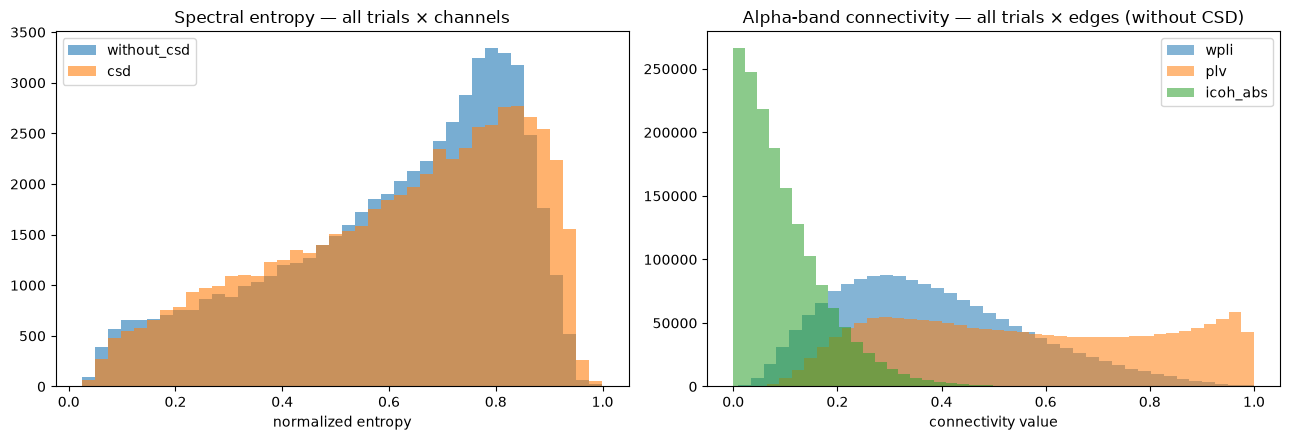

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(np.asarray(dataset.nodes["without_csd"])[:, :, -1].ravel(), bins=40, alpha=0.6, label="without_csd")
axes[0].hist(np.asarray(dataset.nodes["csd"])[:, :, -1].ravel(), bins=40, alpha=0.6, label="csd")
axes[0].set_title("Spectral entropy — all trials × channels")
axes[0].set_xlabel("normalized entropy")
axes[0].legend()

for method in ("wpli", "plv", "icoh_abs"):
    axes[1].hist(
        np.asarray(dataset.edges[f"{method}_without_csd"])[:, :, alpha_index].ravel(),
        bins=40, alpha=0.55, label=method,
    )
axes[1].set_title("Alpha-band connectivity — all trials × edges (without CSD)")
axes[1].set_xlabel("connectivity value")
axes[1].legend()
fig.tight_layout()
plt.show()

## Summary

- Loaded `data/moabb/Graph-Liu2024-VersionOne/` through the same `saved_dataset.load_dataset()` API
  experiments use, and re-ran `validate_saved_dataset()` live against it.
- Confirmed 2,000 trials across 50 subjects, 40 trials each (20/20 left/right), matching both the
  freshly recomputed report and the archived `validation_report.json`.
- Inspected one example trial's six node features in both signal variants, reconstructed dense
  adjacency matrices for all three connectivity methods from the saved `edge_index`/`edge_attr`, and
  confirmed they are symmetric, zero-diagonal, and within `[0, 1]`.
- Exercised `get_graph()` — the actual consumer-facing API — and confirmed it returns independent
  copies rather than views into the memory-mapped arrays.
- Re-ran shape/finiteness/range/reverse-edge/label checks across the *entire* saved dataset, not just
  one trial.

Further detail lives in `DATASET_PLAN.md` (specification, including current-vs-planned Python
organization) and `README.md` (implementation and calculation choices).